In [1]:
import torch

x = torch.tensor([1.0, 2.0])          # 一个点 / 一个向量
M = torch.tensor([[2.0, 0.0],
                  [0.0, 3.0]])         # 一台机器：横向拉 2 倍，纵向拉 3 倍

print(M @ x)      

tensor([2., 6.])


In [2]:
import torch

a = torch.tensor([1.0, 0.0])          # 指向正右
b = torch.tensor([0.0, 1.0])          # 指向正上
c = torch.tensor([1.0, 1.0])          # 指向右上 45°

print(torch.dot(a, b))   # 0.0  —— 垂直，毫不相关
print(torch.dot(a, c))   # 1.0  —— 有点同向
print(torch.dot(a, a))   # 1.0  —— 和自己最同向

tensor(0.)
tensor(1.)
tensor(1.)


In [3]:
import torch

M = torch.tensor([[2.0, 0.0],
                  [0.0, 3.0]])         # 横向拉 2 倍，纵向拉 3 倍

points = torch.tensor([[1.0, 0.0],     # 右
                       [0.0, 1.0],     # 上
                       [1.0, 1.0]])    # 右上角
print(points @ M.t())

tensor([[2., 0.],
        [0., 3.],
        [2., 3.]])


In [4]:
import torch, math

theta = math.radians(30)
rotate  = torch.tensor([[math.cos(theta), -math.sin(theta)],   # 转 30°
                        [math.sin(theta),  math.cos(theta)]])
shear   = torch.tensor([[1.0, 1.0],     # 剪切：越往上越往右滑（像推一摞书）
                        [0.0, 1.0]])
project = torch.tensor([[1.0, 0.0],     # 投影：所有点拍扁到 x 轴
                        [0.0, 0.0]])

v = torch.tensor([1.0, 2.0])
print(rotate  @ v)   # 转了角度，长度不变
print(shear   @ v)   # x 被 y 拖着走
print(project @ v)   # y 变 0，二维塌成一维

tensor([-0.1340,  2.2321])
tensor([3., 2.])
tensor([1., 0.])


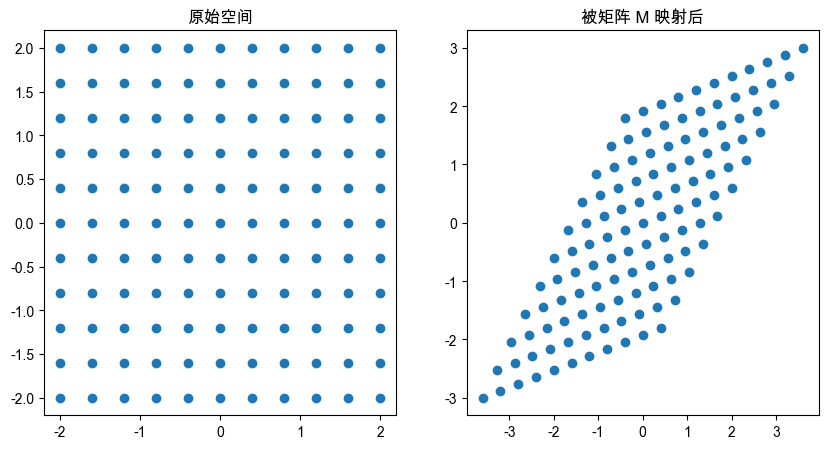

In [7]:
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

xs, ys = torch.meshgrid(torch.linspace(-2, 2, 11),
                        torch.linspace(-2, 2, 11), indexing="xy")
grid = torch.stack([xs.reshape(-1), ys.reshape(-1)], dim=1)

M = torch.tensor([[1.0, 0.8],
                  [0.3, 1.2]])
moved = grid @ M.t()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(grid[:, 0],  grid[:, 1]);  ax[0].set_title("原始空间")
ax[1].scatter(moved[:, 0], moved[:, 1]); ax[1].set_title("被矩阵 M 映射后")
plt.show()

In [1]:
import torch

# 造一批"又高又重"强相关的人：身高和体重几乎成正比
torch.manual_seed(0)
h = torch.randn(500) * 10 + 170        # 身高
w = h * 0.6 + torch.randn(500) * 2     # 体重 ≈ 0.6*身高 + 噪声
data = torch.stack([h, w], dim=1)
data = data - data.mean(0)             # 去均值（PCA 第一步）

# 协方差矩阵的"特征向量" = 数据散布得最开的方向
cov = (data.T @ data) / len(data)
vals, vecs = torch.linalg.eigh(cov)
print("两个方向上的方差(特征值):", vals)        # 一大一小
print("最大特征值对应的方向:", vecs[:, -1])     # 指向"又高又重"那条对角线


两个方向上的方差(特征值): tensor([  3.1782, 142.4883])
最大特征值对应的方向: tensor([-0.8441, -0.5362])
